# Speech Emotion Recognition — v2 (Full Dataset, Speaker-Independent, CNN-BiLSTM)

This notebook rebuilds the emotion recognition model from scratch with three
fixes over the original version:

1. **Trains on the full RAVDESS speech set** (all 24 actors, ~1,440 files) instead of a single actor folder (~60 files).
2. **Splits by speaker**, not randomly — the original random split let the model partly learn to recognize *voices* rather than *emotions*, which inflates accuracy in a way that doesn't generalize to a new speaker (like whoever tries the live demo).
3. **Uses a CNN + BiLSTM over frame-level features** (MFCC + deltas + chroma + spectral contrast + pitch proxy) instead of a single MFCC vector averaged over the whole clip — so the model can learn how emotion unfolds over time, not just a static snapshot.

It also adds data augmentation, class-weighted training, and full evaluation
(confusion matrix, per-class F1, error analysis) so every number in your
README/LinkedIn post is backed by something real.

**Before running:** upload the RAVDESS "Audio_Speech_Actors_01-24" folder to
your Google Drive (download from https://zenodo.org/record/1188976 — the
`Audio_Speech_Actors_01-24.zip` file, ~200MB, is enough; you don't need the
video/song files).


## 1. Setup

In [3]:
# Cell: Install & imports
!pip install librosa soundfile -q

import os
import json
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, Dropout,
    MaxPooling1D, Bidirectional, LSTM, Dense, GlobalAveragePooling1D,
    Multiply, Permute, RepeatVector, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)


TensorFlow: 2.20.0
Librosa: 0.11.0


In [5]:
# Cell: Mount Drive & configure paths
from google.colab import drive
drive.mount('/content/drive/')

DATASET_PATH = '/content/drive/My Drive/Ravdess/Audio_Speech_Actors_01-24'
ARTIFACT_DIR = '/content/drive/My Drive/emotion_model_v2'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

EMOTIONS = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}
EMOTION_LABELS = [EMOTIONS[k] for k in sorted(EMOTIONS)]  # canonical class order

# Audio/feature config — save this alongside the model so app.py can
# reproduce identical preprocessing at inference time.
CONFIG = {
    'sr': 22050,
    'duration': 3.0,          # seconds, clips padded/truncated to this
    'n_mfcc': 40,
    'n_chroma': 12,
    'n_contrast_bands': 7,
    'hop_length': 512,
    'max_frames': 130,        # time steps after pad/truncate (~3s at sr=22050, hop=512)
}
CONFIG['n_features'] = CONFIG['n_mfcc'] * 3 + CONFIG['n_chroma'] + CONFIG['n_contrast_bands'] + 2  # mfcc+delta+delta2, chroma, contrast, zcr, rms
print(CONFIG)


Mounted at /content/drive/
{'sr': 22050, 'duration': 3.0, 'n_mfcc': 40, 'n_chroma': 12, 'n_contrast_bands': 7, 'hop_length': 512, 'max_frames': 130, 'n_features': 141}


In [6]:
import shutil, time

t0 = time.time()
local_path = '/content/Ravdess/Audio_Speech_Actors_01-24'
shutil.copytree(DATASET_PATH, local_path)
print(f"Copied in {time.time()-t0:.0f}s")

DATASET_PATH = local_path  # point everything at the local copy from now on

Copied in 604s


In [15]:
# Cell: Verify dataset — should find all 24 actor folders
assert os.path.exists(DATASET_PATH), f"Dataset path not found: {DATASET_PATH}"
actors = sorted([d for d in os.listdir(DATASET_PATH) if d.startswith('Actor_')])
print(f"Found {len(actors)} actor folders (expect 24)")

all_files = []
for actor in actors:
    actor_path = os.path.join(DATASET_PATH, actor)
    wavs = [f for f in os.listdir(actor_path) if f.lower().endswith('.wav')]
    for w in wavs:
        all_files.append((os.path.join(actor_path, w), w, actor))

print(f"Total audio files found: {len(all_files)} (RAVDESS speech set expects 1440)")
if len(all_files) < 1000:
    print("WARNING: expected ~1440 files. Check that all actor folders were uploaded to Drive.")


Found 24 actor folders (expect 24)
Total audio files found: 1440 (RAVDESS speech set expects 1440)


## 2. Feature extraction

Frame-level features instead of a single averaged vector: MFCC + delta +
delta-delta (captures how the spectral envelope *changes* over time, not
just its average), chroma (tonal content), spectral contrast (peak/valley
energy — useful for angry vs. calm), zero-crossing rate and RMS energy
(noisiness / loudness, both correlate with arousal). Each clip becomes a
`(time_steps, n_features)` matrix, padded/truncated to a fixed length so the
whole dataset can be stacked into one array.

In [13]:
# Cell: Feature extraction function
def extract_frame_features(y, sr, cfg=CONFIG):
    """Return a (max_frames, n_features) matrix of frame-level audio features."""
    hop = cfg['hop_length']

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=cfg['n_mfcc'], hop_length=hop)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=hop)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=hop)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop)
    rms = librosa.feature.rms(y=y, hop_length=hop)

    feats = np.vstack([mfcc, mfcc_delta, mfcc_delta2, chroma, contrast, zcr, rms])  # (n_features, n_frames)
    feats = feats.T  # (n_frames, n_features)

    # Pad or truncate to a fixed number of time steps
    max_frames = cfg['max_frames']
    if feats.shape[0] < max_frames:
        pad_width = max_frames - feats.shape[0]
        feats = np.pad(feats, ((0, pad_width), (0, 0)), mode='constant')
    else:
        feats = feats[:max_frames, :]

    return feats.astype(np.float32)


def load_audio(file_path, cfg=CONFIG):
    y, sr = librosa.load(file_path, sr=cfg['sr'], duration=cfg['duration'])
    target_len = int(cfg['sr'] * cfg['duration'])
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y, sr


## 3. Augmentation

Applied only to the **training** split, after the speaker split (see next
section) — augmenting before splitting would let augmented copies of a
speaker leak into both train and test, which quietly inflates test accuracy.

In [16]:
# Cell: Augmentation functions (operate on raw waveform, before feature extraction)
def add_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return (y + noise_factor * noise).astype(np.float32)

def pitch_shift(y, sr, n_steps):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def time_stretch(y, rate):
    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    # re-pad/truncate to original length
    if len(y_stretched) < len(y):
        y_stretched = np.pad(y_stretched, (0, len(y) - len(y_stretched)))
    else:
        y_stretched = y_stretched[:len(y)]
    return y_stretched.astype(np.float32)

def augment_waveform(y, sr):
    """Returns a list of augmented variants of y (does not include the original)."""
    variants = []
    variants.append(add_noise(y, noise_factor=0.004))
    variants.append(pitch_shift(y, sr, n_steps=np.random.uniform(-2, 2)))
    variants.append(time_stretch(y, rate=np.random.uniform(0.85, 1.15)))
    return variants


## 4. Build the dataset

Speaker-independent split: actors 1–19 for train/val, actors 20–24 held out
entirely for test. This means the model has genuinely never heard those five
voices during training — a fair proxy for how it'll perform on a stranger's
voice through the Streamlit demo.

In [18]:
# Cell: Extract features for a file list, with optional augmentation (train only)
def build_split(file_list, cfg=CONFIG, augment=False):
    X, y = [], []
    for path, fname, actor in tqdm(file_list, desc="augment" if augment else "extract"):
        try:
            emotion_code = fname.split('-')[2]
            audio, sr = load_audio(path, cfg)

            X.append(extract_frame_features(audio, sr, cfg))
            y.append(emotion_code)

            if augment:
                for variant in augment_waveform(audio, sr):
                    X.append(extract_frame_features(variant, sr, cfg))
                    y.append(emotion_code)
        except Exception as e:
            print(f"Skipped {fname}: {e}")
    return np.array(X), np.array(y)

X_train, y_train_raw = build_split(train_files, augment=True)
X_val, y_val_raw     = build_split(val_files, augment=False)
X_test, y_test_raw   = build_split(test_files, augment=False)

print("Shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train_raw.shape)
print("  X_val:  ", X_val.shape,   " y_val:  ", y_val_raw.shape)
print("  X_test: ", X_test.shape,  " y_test: ", y_test_raw.shape)


augment:   0%|          | 0/960 [00:00<?, ?it/s]

extract:   0%|          | 0/180 [00:00<?, ?it/s]

extract:   0%|          | 0/300 [00:00<?, ?it/s]

Shapes:
  X_train: (3840, 130, 141)  y_train: (3840,)
  X_val:   (180, 130, 141)  y_val:   (180,)
  X_test:  (300, 130, 141)  y_test:  (300,)


In [17]:
# Cell: Speaker-independent split (before any feature extraction/augmentation)
TEST_ACTORS = {'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24'}
VAL_ACTORS  = {'Actor_17', 'Actor_18', 'Actor_19'}

train_files, val_files, test_files = [], [], []
for path, fname, actor in all_files:
    if actor in TEST_ACTORS:
        test_files.append((path, fname, actor))
    elif actor in VAL_ACTORS:
        val_files.append((path, fname, actor))
    else:
        train_files.append((path, fname, actor))

print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_files)}")


Train files: 960 | Val files: 180 | Test files: 300


## 5. Encode labels & scale features

The scaler is **fit on training data only** and reused (not refit) on
val/test — fitting it on the full dataset would leak test-set statistics
into preprocessing. The fitted scaler and label encoder are saved so
`app.py` can apply the exact same transform to a new recording at
inference time.

In [19]:
# Cell: Label encoding
le = LabelEncoder()
le.fit(sorted(EMOTIONS.keys()))  # fixed order '01'..'08', independent of what's present in train

y_train_int = le.transform(y_train_raw)
y_val_int   = le.transform(y_val_raw)
y_test_int  = le.transform(y_test_raw)

y_train_oh = to_categorical(y_train_int, num_classes=8)
y_val_oh   = to_categorical(y_val_int, num_classes=8)
y_test_oh  = to_categorical(y_test_int, num_classes=8)

class_names = [EMOTIONS[c] for c in le.classes_]
print("Class order:", class_names)


Class order: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


In [20]:
# Cell: Feature scaling (fit on train only, applied per-timestep)
n_samples_tr, n_steps, n_feats = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, n_feats))

def scale_3d(X, scaler, n_steps, n_feats):
    flat = X.reshape(-1, n_feats)
    flat = scaler.transform(flat)
    return flat.reshape(-1, n_steps, n_feats)

X_train_s = scale_3d(X_train, scaler, n_steps, n_feats)
X_val_s   = scale_3d(X_val, scaler, n_steps, n_feats)
X_test_s  = scale_3d(X_test, scaler, n_steps, n_feats)

print(X_train_s.shape, X_val_s.shape, X_test_s.shape)


(3840, 130, 141) (180, 130, 141) (300, 130, 141)


In [21]:
# Cell: Class weights (RAVDESS has half as many 'neutral' samples — no strong-intensity variant)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", {class_names[i]: round(w, 2) for i, w in class_weight_dict.items()})


Class weights: {'neutral': np.float64(1.88), 'calm': np.float64(0.94), 'happy': np.float64(0.94), 'sad': np.float64(0.94), 'angry': np.float64(0.94), 'fearful': np.float64(0.94), 'disgust': np.float64(0.94), 'surprised': np.float64(0.94)}


## 6. Model — CNN + BiLSTM with attention

- **Conv1D blocks** extract local spectral patterns per time window.
- **BiLSTM** models how those patterns evolve across the utterance in both directions.
- **Attention layer** learns to weight the most emotionally salient frames instead of averaging all of them equally — e.g. the moment someone's voice cracks or spikes matters more than a flat, silent lead-in.

In [22]:
# Cell: Attention layer + model definition
def attention_block(inputs):
    # inputs: (batch, time_steps, features)
    time_steps = inputs.shape[1]
    scores = Dense(1, activation='tanh')(inputs)                # (batch, time, 1)
    scores = tf.keras.layers.Softmax(axis=1)(scores)             # attention weights over time
    context = Multiply()([inputs, scores])                       # weight each timestep
    context = Lambda(lambda x: tf.reduce_sum(x, axis=1))(context)  # (batch, features)
    return context, scores


def build_model(input_shape, n_classes=8):
    inp = Input(shape=input_shape)

    x = Conv1D(128, 5, padding='same')(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Conv1D(128, 5, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    context, attn_weights = attention_block(x)

    x = Dense(64, activation='relu')(context)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out, name='emotion_cnn_bilstm_attention')
    attn_model = Model(inputs=inp, outputs=attn_weights, name='attention_extractor')
    return model, attn_model

model, attn_model = build_model(input_shape=(n_steps, n_feats))
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "emotion_cnn_bilstm_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 130, 141)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 130, 128)  │     90,368 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 130, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 130, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 130, 128)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 65, 128)   │          0 │ dropout[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 65, 128)   │     82,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 65, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 65, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 65, 128)   │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 65, 128)   │     98,816 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 65, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 65, 1)     │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 65, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 65, 128)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        520 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 281,161 (1.07 MB)

 Trainable params: 280,649 (1.07 MB)

 Non-trainable params: 512 (2.00 KB)

## 7. Train

In [23]:
# Cell: Callbacks
checkpoint_path = os.path.join(ARTIFACT_DIR, 'best_model.h5')

callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
]


In [24]:
# Cell: Fit
history = model.fit(
    X_train_s, y_train_oh,
    validation_data=(X_val_s, y_val_oh),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/150
117/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2528 - loss: 1.8822
Epoch 1: val_accuracy improved from None to 0.40000, saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5



Epoch 1: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3471 - loss: 1.6703 - val_accuracy: 0.4000 - val_loss: 2.1665 - learning_rate: 0.0010
Epoch 2/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5735 - loss: 1.1698
Epoch 2: val_accuracy improved from 0.40000 to 0.44444, saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5



Epoch 2: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6109 - loss: 1.0747 - val_accuracy: 0.4444 - val_loss: 2.0607 - learning_rate: 0.0010
Epoch 3/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7211 - loss: 0.8063
Epoch 3: val_accuracy improved from 0.44444 to 0.50000, saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5



Epoch 3: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7487 - loss: 0.7380 - val_accuracy: 0.5000 - val_loss: 1.8666 - learning_rate: 0.0010
Epoch 4/150
118/120 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8105 - loss: 0.5645
Epoch 4: val_accuracy did not improve from 0.50000
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8216 - loss: 0.5368 - val_accuracy: 0.4556 - val_loss: 2.6358 - learning_rate: 0.0010
Epoch 5/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8452 - loss: 0.4568
Epoch 5: val_accuracy improved from 0.50000 to 0.50556, saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5



Epoch 5: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8490 - loss: 0.4474 - val_accuracy: 0.5056 - val_loss: 2.1860 - learning_rate: 0.0010
Epoch 6/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8839 - loss: 0.3581
Epoch 6: val_accuracy improved from 0.50556 to 0.52222, saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5



Epoch 6: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8997 - loss: 0.3001 - val_accuracy: 0.5222 - val_loss: 2.3963 - learning_rate: 0.0010
Epoch 7/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9053 - loss: 0.2881
Epoch 7: val_accuracy improved from 0.52222 to 0.54444, saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5



Epoch 7: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9117 - loss: 0.2671 - val_accuracy: 0.5444 - val_loss: 2.3038 - learning_rate: 0.0010
Epoch 8/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9176 - loss: 0.2531
Epoch 8: val_accuracy did not improve from 0.54444
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9203 - loss: 0.2442 - val_accuracy: 0.5056 - val_loss: 2.5965 - learning_rate: 0.0010
Epoch 9/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9323 - loss: 0.1925
Epoch 9: val_accuracy did not improve from 0.54444
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9352 - loss: 0.1930 - val_accuracy: 0.5000 - val_loss: 2.6266 - learning_rate: 0.0010
Epoch 10/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9470 - loss: 0.1674
Epoch 10: val_accuracy did not improve from 0.54444
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9469 - lo


Epoch 16: finished saving model to /content/drive/My Drive/emotion_model_v2/best_model.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9862 - loss: 0.0397 - val_accuracy: 0.5500 - val_loss: 3.2510 - learning_rate: 5.0000e-04
Epoch 17/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9887 - loss: 0.0312
Epoch 17: val_accuracy did not improve from 0.55000
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9904 - loss: 0.0305 - val_accuracy: 0.5056 - val_loss: 4.2558 - learning_rate: 5.0000e-04
Epoch 18/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9903 - loss: 0.0357
Epoch 18: val_accuracy did not improve from 0.55000
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9880 - loss: 0.0373 - val_accuracy: 0.5111 - val_loss: 3.4838 - learning_rate: 5.0000e-04
Epoch 19/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9884 - loss: 0.0388
Epoch 19: val_accuracy did not improve from 0.55000

Epoch 19: ReduceLROnPlateau reducing learning r

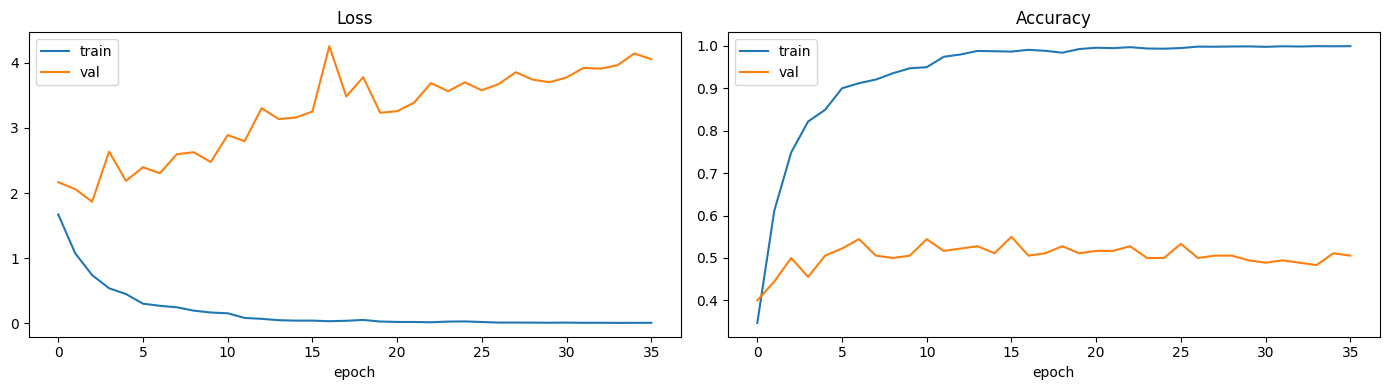

In [25]:
# Cell: Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'training_curves.png'), dpi=150)
plt.show()


## 8. Evaluate on the held-out speakers

This is the number that goes in your README — it's measured on five actors
the model never saw during training, so it's a genuine estimate of how it'll
perform on a new voice through the live demo.

In [28]:
# Cell: Load best checkpoint and evaluate on test set
# Cell: Rebuild architecture, then load only the trained weights
best_model, attn_model = build_model(input_shape=(n_steps, n_feats))
best_model.load_weights(checkpoint_path)
best_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

test_loss, test_acc = best_model.evaluate(X_test_s, y_test_oh, verbose=0)
print(f"Held-out (speaker-independent) test accuracy: {test_acc*100:.2f}%")

y_pred_probs = best_model.predict(X_test_s)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_int

print(classification_report(y_true, y_pred, target_names=class_names))


Held-out (speaker-independent) test accuracy: 58.00%
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
              precision    recall  f1-score   support

     neutral       0.54      0.35      0.42        20
        calm       0.63      0.85      0.72        40
       happy       0.39      0.38      0.38        40
         sad       0.45      0.42      0.44        40
       angry       0.56      0.68      0.61        40
     fearful       0.56      0.23      0.32        40
     disgust       0.66      0.68      0.67        40
   surprised       0.73      0.95      0.83        40

    accuracy                           0.58       300
   macro avg       0.57      0.57      0.55       300
weighted avg       0.57      0.58      0.56       300



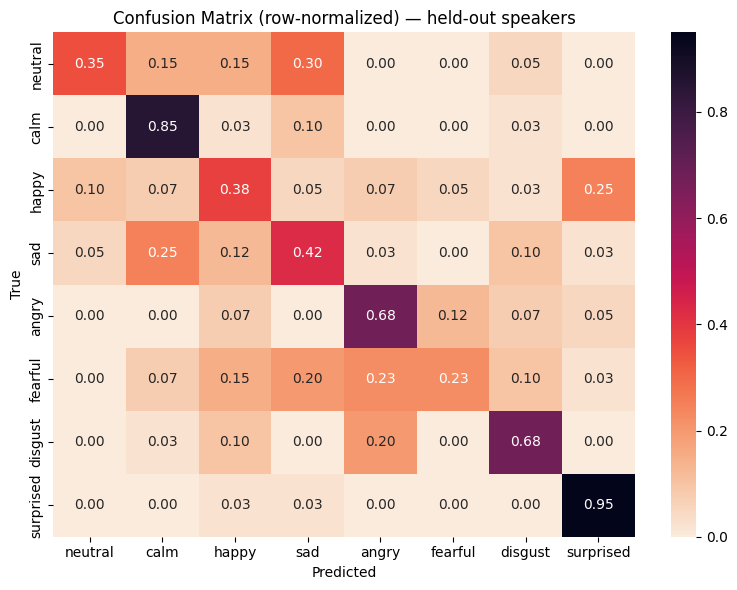

In [29]:
# Cell: Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='rocket_r',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (row-normalized) — held-out speakers')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()


## 9. Error analysis

Fill this in after looking at the confusion matrix above — this paragraph is
your best material for the LinkedIn post and for talking through the project
in an interview. Look specifically at:
- Which emotion pairs get confused most (fear/surprise and calm/neutral are
  the classic RAVDESS confusions — both pairs share similar pitch/energy
  signatures, which is exactly the kind of subtlety MFCCs alone struggle to
  separate).
- Whether errors cluster on any particular actor (a sign that actor's
  recording differs acoustically — mic distance, accent, etc.)
- Whether high-arousal emotions (angry, happy, fearful, surprised) are
  easier to separate from low-arousal ones (calm, sad, neutral) than
  same-arousal pairs are from each other — a useful axis to discuss even if
  you don't build a two-stage classifier.

In [30]:
# Cell: Per-class accuracy + most-confused pairs (for your error analysis writeup)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for name, acc in sorted(zip(class_names, per_class_acc), key=lambda x: x[1]):
    print(f"  {name:12s}: {acc*100:5.1f}%")

print()
print("Most confused pairs (true -> predicted, count):")
confusions = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confusions.append((class_names[i], class_names[j], cm[i, j]))
for true_c, pred_c, count in sorted(confusions, key=lambda x: -x[2])[:8]:
    print(f"  {true_c:10s} -> {pred_c:10s}: {count}")


  fearful     :  22.5%
  neutral     :  35.0%
  happy       :  37.5%
  sad         :  42.5%
  angry       :  67.5%
  disgust     :  67.5%
  calm        :  85.0%
  surprised   :  95.0%

Most confused pairs (true -> predicted, count):
  happy      -> surprised : 10
  sad        -> calm      : 10
  fearful    -> angry     : 9
  fearful    -> sad       : 8
  disgust    -> angry     : 8
  neutral    -> sad       : 6
  fearful    -> happy     : 6
  sad        -> happy     : 5


## 10. Attention visualization (explainability)

Shows which time frames of a sample clip the model weighted most heavily —
a nice visual for the LinkedIn post (spectrogram + attention overlay is far
more compelling than a bar chart of probabilities).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


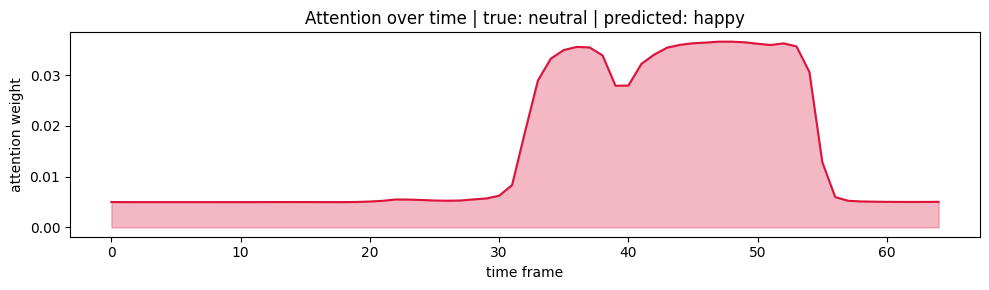

In [31]:
# Cell: Visualize attention weights for one test sample
sample_idx = 0
sample_X = X_test_s[sample_idx:sample_idx+1]
sample_true = class_names[y_true[sample_idx]]
sample_pred = class_names[y_pred[sample_idx]]

attn_weights = attn_model.predict(sample_X)[0, :, 0]  # (time_steps,)

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(attn_weights, color='crimson')
ax1.fill_between(range(len(attn_weights)), attn_weights, alpha=0.3, color='crimson')
ax1.set_title(f"Attention over time | true: {sample_true} | predicted: {sample_pred}")
ax1.set_xlabel('time frame')
ax1.set_ylabel('attention weight')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'attention_example.png'), dpi=150)
plt.show()


## 11. Save everything the app needs for deployment

In [32]:
# Cell: Save model, scaler, label encoder, and feature config together
import joblib

best_model.save(os.path.join(ARTIFACT_DIR, 'emotion_model.h5'))
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, 'scaler.pkl'))
joblib.dump(le, os.path.join(ARTIFACT_DIR, 'label_encoder.pkl'))

with open(os.path.join(ARTIFACT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(CONFIG, f, indent=2)

# Save final metrics for the README
metrics_summary = {
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'per_class_accuracy': {name: float(acc) for name, acc in zip(class_names, per_class_acc)},
    'n_train_samples': int(X_train.shape[0]),
    'n_val_samples': int(X_val.shape[0]),
    'n_test_samples': int(X_test.shape[0]),
    'test_actors_held_out': sorted(list(TEST_ACTORS)),
}
with open(os.path.join(ARTIFACT_DIR, 'metrics_summary.json'), 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved to:", ARTIFACT_DIR)
print(json.dumps(metrics_summary, indent=2))


Saved to: /content/drive/My Drive/emotion_model_v2
{
  "test_accuracy": 0.5799999833106995,
  "test_loss": 2.3277010917663574,
  "per_class_accuracy": {
    "neutral": 0.35,
    "calm": 0.85,
    "happy": 0.375,
    "sad": 0.425,
    "angry": 0.675,
    "fearful": 0.225,
    "disgust": 0.675,
    "surprised": 0.95
  },
  "n_train_samples": 3840,
  "n_val_samples": 180,
  "n_test_samples": 300,
  "test_actors_held_out": [
    "Actor_20",
    "Actor_21",
    "Actor_22",
    "Actor_23",
    "Actor_24"
  ]
}


In [33]:
# Cell: Download the deployment bundle locally (model + scaler + encoder + config)
from google.colab import files
import shutil

bundle_dir = '/content/emotion_model_bundle'
os.makedirs(bundle_dir, exist_ok=True)
for fname in ['emotion_model.h5', 'scaler.pkl', 'label_encoder.pkl', 'feature_config.json', 'metrics_summary.json']:
    shutil.copy(os.path.join(ARTIFACT_DIR, fname), os.path.join(bundle_dir, fname))

shutil.make_archive('/content/emotion_model_bundle', 'zip', bundle_dir)
files.download('/content/emotion_model_bundle.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next step

Unzip `emotion_model_bundle.zip` into your repo (e.g. as a `model/` folder).
It contains everything `app.py` needs: `emotion_model.h5`, `scaler.pkl`,
`label_encoder.pkl`, `feature_config.json`, and `metrics_summary.json` (use
the numbers in this file for your README — they're honest, speaker-held-out
numbers you can defend in an interview).

Bring `metrics_summary.json` and the two PNGs (`confusion_matrix.png`,
`training_curves.png`) back to this conversation and I'll build the updated
`app.py`, README, and repo structure around the real results.